# NRDI: physics-verified periorbital wearable with multimodal AI for joint diabetic retinopathy and neuropathy screening

This notebook reproduces every headline number of the project from the stored outputs. It reads
`results/RESULTS_MASTER.json` (the single source of numbers) and the per-subject prediction files in `results/out/`,
recomputes the metrics live with scikit-learn, and draws the plots. No raw images or patient rows are loaded here;
retraining is done by the scripts in `results/src/` (see the README).

Datasets (all public or open): DeepDRiD (CC BY-SA 4.0), IDRiD (CC BY 4.0), APTOS 2019 (Kaggle), Istanbul e-Nabız EHR export
(Mendeley Data, CC BY 4.0), PhysioNet Novak-lab diabetes cohorts (CC BY 4.0), PPG-BP (figshare, CC0). Links are in the README.

In [1]:
import json, pathlib, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, cohen_kappa_score, confusion_matrix
ROOT = pathlib.Path.cwd()
while not (ROOT / "results" / "RESULTS_MASTER.json").exists(): ROOT = ROOT.parent
OUT = ROOT / "results" / "out"; SIM = ROOT / "sim" / "out"
M = json.loads((ROOT / "results" / "RESULTS_MASTER.json").read_text(encoding="utf-8"))
def v(*ks):
    d = M
    for k in ks: d = d[k]
    return d["value"] if isinstance(d, dict) and "value" in d else d
def ci(*ks):
    d = M
    for k in ks: d = d[k]
    return d.get("ci95")
print("results master built", M["_meta"]["built"], "|", len(M), "sections")

results master built 2026-09-08T07:46:29 | 20 sections


## 1. Fundus retinopathy grader (ConvNeXt-Tiny, ordinal regression, patient-grouped 5-fold on DeepDRiD)
Out-of-fold predictions are in `fundus_oof.npz`; the four thresholds fitted on them are applied unchanged to IDRiD and APTOS 2019.

In [2]:
# our own outputs (object arrays hold image paths), so allow_pickle is safe
Z = np.load(OUT / "fundus_oof.npz", allow_pickle=True); I = np.load(OUT / "fundus_idrid_pred.npz", allow_pickle=True); A = np.load(OUT / "fundus_aptos_pred.npz", allow_pickle=True)
th = np.array(v("fundus_dr", "thresholds")); m = ~np.isnan(Z["oof"])
grade = lambda s: np.digitize(s, np.sort(th))
rows = []
for name, y, s in (("DeepDRiD OOF (China)", Z["grade"][m], Z["oof"][m]), ("IDRiD external (India)", I["grade"], I["pred"]), ("APTOS 2019 external (India)", A["grade"], A["pred"])):
    g = grade(s)
    rows.append({"dataset": name, "n": len(y), "QWK": cohen_kappa_score(y, g, weights="quadratic"), "AUC referable": roc_auc_score(y >= 2, s), "accuracy": (g == y).mean(),
                 "sensitivity": ((g >= 2) & (y >= 2)).sum() / (y >= 2).sum(), "specificity": ((g < 2) & (y < 2)).sum() / (y < 2).sum()})
df = pd.DataFrame(rows).set_index("dataset").round(3); df

,n,QWK,AUC referable,accuracy,sensitivity,specificity
dataset,,,,,,
DeepDRiD OOF (China),1589,0.857,0.970,0.685,0.901,0.933
IDRiD external (India),516,0.729,0.952,0.450,0.938,0.715
APTOS 2019 external (India),3662,0.845,0.979,0.552,0.990,0.848


master says: OOF QWK 0.857 [0.8348696995260773, 0.8776324753621546] | APTOS QWK 0.845 | APTOS re-fitted thresholds (reported, not used): 0.878


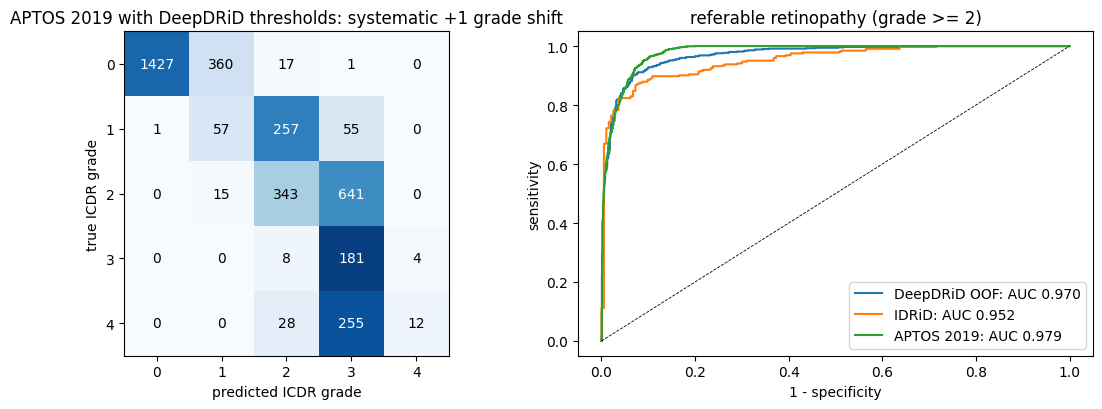

In [3]:
print("master says: OOF QWK", round(v("fundus_dr","qwk"),3), ci("fundus_dr","qwk"), "| APTOS QWK", round(v("fundus_external_aptos","qwk"),3), "| APTOS re-fitted thresholds (reported, not used):", round(v("fundus_external_aptos","refit_qwk_not_used"),3))
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
cm = confusion_matrix(A["grade"], grade(A["pred"]), labels=range(5))
im = ax[0].imshow(cm / cm.sum(1, keepdims=True), cmap="Blues", vmin=0, vmax=1)
for i in range(5):
    for j in range(5): ax[0].text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] / cm[i].sum() > 0.5 else "black")
ax[0].set_xlabel("predicted ICDR grade"); ax[0].set_ylabel("true ICDR grade"); ax[0].set_title("APTOS 2019 with DeepDRiD thresholds: systematic +1 grade shift")
for name, y, s in (("DeepDRiD OOF", Z["grade"][m], Z["oof"][m]), ("IDRiD", I["grade"], I["pred"]), ("APTOS 2019", A["grade"], A["pred"])):
    f, t, _ = roc_curve(y >= 2, s); ax[1].plot(f, t, label=f"{name}: AUC {roc_auc_score(y >= 2, s):.3f}")
ax[1].plot([0, 1], [0, 1], "k--", lw=0.6); ax[1].set_xlabel("1 - specificity"); ax[1].set_ylabel("sensitivity"); ax[1].set_title("referable retinopathy (grade >= 2)"); ax[1].legend()
plt.tight_layout(); plt.show()

## 2. Macular edema head (IDRiD, DME grade 0 to 2)

In [4]:
D = np.load(OUT / "dme_idrid_pred.npz"); thd = np.array(v("dme", "thresholds"))
print("OOF (413 images): QWK", round(cohen_kappa_score(D["y_train"], np.digitize(D["oof"], np.sort(thd)), weights="quadratic"), 3), "| any-DME AUC", round(roc_auc_score(D["y_train"] >= 1, D["oof"]), 3))
print("fixed test (103 images): QWK", round(cohen_kappa_score(D["y_test"], np.digitize(D["test_pred"], np.sort(thd)), weights="quadratic"), 3), "| any-DME AUC", round(roc_auc_score(D["y_test"] >= 1, D["test_pred"]), 3))
ct = pd.crosstab(pd.Series(I["grade"], name="DR grade"), pd.Series(I["dme"], name="DME grade")); ct

OOF (413 images): QWK 0.916 | any-DME AUC 0.982
fixed test (103 images): QWK 0.838 | any-DME AUC 0.945


DME grade,0,1,2
DR grade,,,
0,168,0,0
1,25,0,0
2,16,36,116
3,6,7,80
4,7,8,47


## 3. Systemic branch on routine records (Istanbul export, n = 77,724)
The neuropathy model **excludes treatment proxies** (antiepileptics = gabapentin/pregabalin, ATC A16 = alpha-lipoic acid, other nervous-system drugs).
They follow the diagnosis rather than precede it. Keeping them inflates the AUC to 0.838; the honest number is 0.710.

In [5]:
E = np.load(OUT / "ehr_oof.npz")
rows = [("retinopathy, logistic", E["y_dr"], E["retinopathy_logistic"]), ("retinopathy, boosted", E["y_dr"], E["retinopathy_hgb"]),
        ("neuropathy, logistic (proxies excluded)", E["y_dn"], E["diabetic_neuropathy_logistic"]), ("neuropathy, boosted (proxies excluded)  <- reported", E["y_dn"], E["diabetic_neuropathy_hgb"]),
        ("sensitivity: neuropathy WITH treatment proxies", E["y_dn"], E["DN_with_proxies_hgb"]), ("sensitivity: also without analgesics/psychoanaleptics", E["y_dn"], E["DN_wide_exclusion_hgb"])]
pd.DataFrame([{"model": n, "n": len(y), "prevalence": y.mean().round(4), "AUC (5-fold OOF)": round(roc_auc_score(y, p), 3)} for n, y, p in rows]).set_index("model")

,n,prevalence,AUC (5-fold OOF)
model,,,
"retinopathy, logistic",77724,0.1399,0.710
"retinopathy, boosted",77724,0.1399,0.720
"neuropathy, logistic (proxies excluded)",77724,0.1734,0.703
"neuropathy, boosted (proxies excluded) <- reported",77724,0.1734,0.710
sensitivity: neuropathy WITH treatment proxies,77724,0.1734,0.838
sensitivity: also without analgesics/psychoanaleptics,77724,0.1734,0.708


In [6]:
jo = M["ehr"]["joint_ovr_auc"]["value"]; cnt = M["ehr"]["joint_counts"]["value"]
print("joint 4-class one-vs-rest AUC:", {k: round(x, 2) for k, x in jo.items()}, "| counts:", cnt)
print("DR-DN co-occurrence odds ratio", round(v("ehr", "dr_dn_odds_ratio"), 2), "Fisher p", v("ehr", "dr_dn_fisher_p"))
print("top logistic odds ratios per SD (neuropathy):", {k: round(x, 2) for k, x in list(M["ehr"]["diabetic_neuropathy_main_excludes_treatment_proxies"]["logistic_odds_ratio_per_sd_top"]["value"].items())[:5]})

joint 4-class one-vs-rest AUC: {'none': 0.72, 'DR only': 0.68, 'DN only': 0.68, 'both': 0.78} | counts: {'0': 56255, '1': 7994, '2': 10597, '3': 2878}
DR-DN co-occurrence odds ratio 1.91 Fisher p 1.32180626434428e-147
top logistic odds ratios per SD (neuropathy): {'HbA1c': 1.2, 'age': 1.18, 'musculoskeletal_dis': 1.18, 'insulin_aspart': 1.17, 'lipoprotein_met_dis': 1.16}


## 4. Physiological branch: heart-rate variability (PhysioNet) and fingertip PPG (PPG-BP)
One positive result and two honest nulls, each with a positive control.

In [7]:
H = np.load(OUT / "hrv_pred.npz"); P = np.load(OUT / "ppg_pred.npz")
print("HRV: diabetes vs control LOO AUC", round(roc_auc_score(H["dm_vs_control_y"], H["dm_vs_control_p"]), 3), "(n = %d)" % len(H["dm_vs_control_y"]))
print("HRV: retinopathy within diabetics LOO AUC", round(roc_auc_score(H["dr_within_dm_y"], H["dr_within_dm_p"]), 3), "(n = %d, NULL)" % len(H["dr_within_dm_y"]))
print("HRV: autonomic symptoms AUC", round(roc_auc_score(H["autonomic_symptoms_y"], H["autonomic_symptoms_p"]), 3))
for k in ("dm_demographics_only", "dm_morphology", "dm_morphology_plus_demo", "dm_papagei_pca16", "dm_papagei_plus_demo", "htn_morphology"):
    print(f"PPG-BP {k:26s} AUC {roc_auc_score(P[k+'_y'], P[k+'_p']):.3f}")
print("PaPaGei age control: r =", round(np.corrcoef(P["age"], P["age_pred"])[0, 1], 2), "MAE", round(np.mean(np.abs(P["age"] - P["age_pred"])), 1), "years")

HRV: diabetes vs control LOO AUC 0.777 (n = 94)
HRV: retinopathy within diabetics LOO AUC 0.367 (n = 58, NULL)
HRV: autonomic symptoms AUC 0.541
PPG-BP dm_demographics_only       AUC 0.572
PPG-BP dm_morphology              AUC 0.372
PPG-BP dm_morphology_plus_demo    AUC 0.417
PPG-BP dm_papagei_pca16           AUC 0.451
PPG-BP dm_papagei_plus_demo       AUC 0.490
PPG-BP htn_morphology             AUC 0.726
PaPaGei age control: r = 0.38 MAE 13.9 years


## 5. Digital twin: thermal forward model, verification and uncertainty
Numbers come from `sim/out/thermal3d_full.json`, `verification.json` and `surrogate_thermal.json` through the master.

apex 32.96 C, canthus 33.91 C, temple 34.47 C at 25 C ambient; published apex [34.0, 35.0], canthus [35.0, 36.5]
MMS observed order 1.79; max GCI 2.00 %; apex deficit at 50 % choroidal perfusion -0.54 C; thermopile 90 deg captures 28 %, 5 deg 14 %


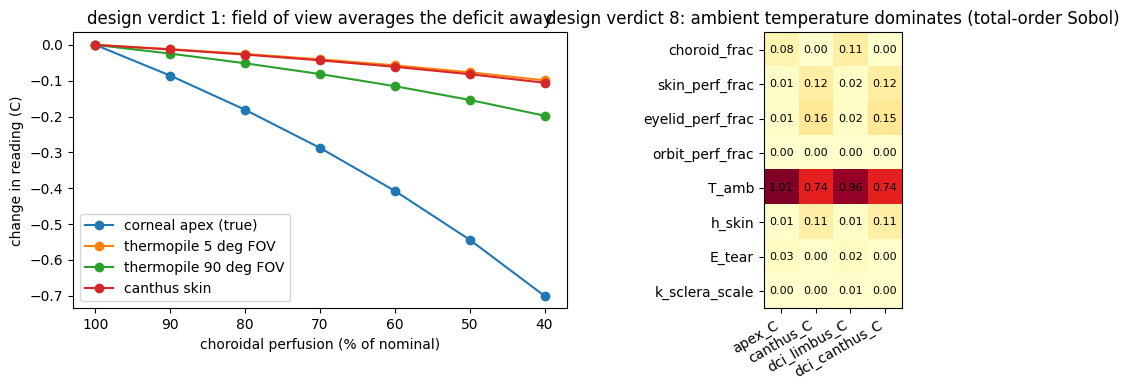

apex slope 0.32 C per C ambient (R2 0.84)


In [8]:
T = M["thermal"]; sw = T["choroid_sweep"]["value"]; base = sw[0]
print("apex %.2f C, canthus %.2f C, temple %.2f C at 25 C ambient; published apex %s, canthus %s" % (v("thermal","corneal_apex_C"), v("thermal","medial_canthus_skin_C"), v("thermal","temple_skin_C"), v("thermal","published_corneal_apex_range_C"), v("thermal","published_inner_canthus_range_C")))
print("MMS observed order %.2f; max GCI %.2f %%; apex deficit at 50 %% choroidal perfusion %.2f C; thermopile 90 deg captures %.0f %%, 5 deg %.0f %%" % (v("verification","observed_order"), v("verification","gci_max_percent"), v("thermal","apex_deficit_at_50pct_choroid_C"), 100*v("thermal","thermopile_90deg_capture_fraction"), 100*v("thermal","thermopile_5deg_capture_fraction")))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
cf = [r["choroid_frac"] * 100 for r in sw]
for k, lab in (("apex_C", "corneal apex (true)"), ("dci_C", "thermopile 5 deg FOV"), ("baa_C", "thermopile 90 deg FOV"), ("canthus_C", "canthus skin")):
    ax[0].plot(cf, [r[k] - base[k] for r in sw], "o-", label=lab)
ax[0].invert_xaxis(); ax[0].set_xlabel("choroidal perfusion (% of nominal)"); ax[0].set_ylabel("change in reading (C)"); ax[0].legend(); ax[0].set_title("design verdict 1: field of view averages the deficit away")
ST = np.array(M["uq"]["ST"]["value"]); params = [p[0] for p in M["uq"]["params_ranges"]["value"]]; outs = M["uq"]["outputs"]["value"]
im = ax[1].imshow(np.clip(ST, 0, 1), cmap="YlOrRd", vmin=0, vmax=1); ax[1].set_xticks(range(len(outs))); ax[1].set_xticklabels(outs, rotation=30, ha="right"); ax[1].set_yticks(range(len(params))); ax[1].set_yticklabels(params)
for i in range(ST.shape[0]):
    for j in range(ST.shape[1]): ax[1].text(j, i, f"{ST[i,j]:.2f}", ha="center", va="center", fontsize=8)
ax[1].set_title("design verdict 8: ambient temperature dominates (total-order Sobol)"); plt.tight_layout(); plt.show()
print("apex slope %.2f C per C ambient (R2 %.2f)" % (v("uq","apex_slope_per_C_ambient"), v("uq","apex_r2_ambient_alone")))

## 6. Optical, electrical and pupil forward models

In [9]:
O = M["optical"]; B = M["bioimpedance"]; Pp = M["pupil"]
print("PPG at 3 mm: arterial share of attenuation 660 nm %.1f %%, 880 nm %.1f %%; at 12 mm the arterial share of the pulse is %.0f %% but photons fall %.1f-fold" % (100*v("optical","ppg_by_wavelength","660","arterial_attenuation_share"), 100*v("optical","ppg_by_wavelength","880","arterial_attenuation_share"), 100*v("optical","artery_share_of_pulse_at_12mm"), v("optical","detected_fraction_ratio_3mm_over_12mm")))
print("940 nm illuminator: IEC 62471 limit %.1f mW; heating at that power apex %.2f C, lid %.2f C, canthus %.2f C" % (v("optical","led","max_led_optical_power_mW"), v("opto_thermal","apex_rise_at_iec_limit_C"), v("opto_thermal","lid_rise_at_iec_limit_C"), v("opto_thermal","canthus_rise_at_iec_limit_C")))
print("bioimpedance at 50 kHz: orbit+eye+lid share %.1f %%; contact share of a bipolar reading %.0f %%; edema +10 %% water -> tetrapolar %.2f %% vs bipolar total %.2f %%" % (100*v("bioimpedance","orbit_share_50kHz"), 100*v("bioimpedance","bipolar_contact_share_of_total_50kHz"), B["edema_50kHz"]["value"]["0.1"]["dZ_abs_percent"], B["edema_50kHz"]["value"]["0.1"]["bipolar_total_dZ_abs_percent"]))
ss = Pp["stimulus_sweep"]["value"]; print("pupil: amplitude at 0 lx %.2f mm (940 nm only) vs %.2f mm at 300 lx; camera under-read %.1f %%" % (ss[0]["amplitude_mm"], [r for r in ss if r["stimulus_lux"] == 300][0]["amplitude_mm"], Pp["camera"]["value"]["naive_underread_percent"]))

PPG at 3 mm: arterial share of attenuation 660 nm 0.7 %, 880 nm 2.1 %; at 12 mm the arterial share of the pulse is 35 % but photons fall 37.5-fold
940 nm illuminator: IEC 62471 limit 42.3 mW; heating at that power apex 0.21 C, lid 0.14 C, canthus 0.06 C
bioimpedance at 50 kHz: orbit+eye+lid share 15.6 %; contact share of a bipolar reading 68 %; edema +10 % water -> tetrapolar -1.39 % vs bipolar total -0.13 %
pupil: amplitude at 0 lx 0.10 mm (940 nm only) vs 2.23 mm at 300 lx; camera under-read 36.9 %


## 7. The eight design verdicts
Each verdict names the master entries behind it (see `results/RESULTS_MASTER.json` -> `design_verdicts`).

In [10]:
for k, val in M["design_verdicts"].items(): print(k, "->", val if isinstance(val, list) else val["paths"])

1_thermopile_90deg_fov_too_wide -> ['thermal.thermopile_90deg_spot_mm', 'thermal.thermopile_90deg_capture_fraction', 'thermal.thermopile_5deg_capture_fraction']
2_940nm_illuminator_evokes_no_reflex -> ['pupil.stimulus_sweep']
3_aim_thermopile_at_ocular_surface_not_canthus -> ['uq.ST_choroid_ocular_readouts', 'uq.S1_choroid_per_output']
4_electrode_contact_model -> ['bioimpedance.electrodes', 'bioimpedance.bipolar_contact_share_of_total_50kHz']
5_3mm_ppg_reads_dermal_plexus_not_artery -> ['optical.ppg_by_wavelength', 'optical.spacing_sweep_880', 'optical.detected_fraction_ratio_3mm_over_12mm']
6_cross_eye_tetrapolar_blind_to_orbit -> ['bioimpedance.orbit_share_50kHz', 'bioimpedance.edema_50kHz']
7_illuminator_heating_confound -> ['opto_thermal.apex_rise_at_iec_limit_C', 'opto_thermal.apex_rise_as_fraction_of_50pct_choroid_deficit']
8_ambient_temperature_dominates_compensate -> ['uq.ST_ambient_range', 'uq.apex_slope_per_C_ambient']


### Integrity notes
* No quantum layer contributed to any result (`results/src/concept_quantum.py` was smoke-tested only and produced no output).
* The neuropathy AUC reported is 0.710 with treatment proxies excluded; 0.838 is a sensitivity analysis only.
* APTOS: ordering transfers (AUC 0.979) but grade boundaries do not (accuracy 55 %); re-fitted thresholds (QWK 0.878) are reported, not used.
* The wearable is a verified design; no prototype has been tested on people and no human data were generated.